In [16]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter
from sklearn.impute import SimpleImputer
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 1. ЗАГРУЗКА ДАННЫХ
# ==============================
print("Загрузка данных...")
train_df = pd.read_csv('train_final.csv')
test_df = pd.read_csv('test_final.csv')

print(f"Тренировочные данные: {len(train_df)} событий, {train_df['user_id'].nunique()} пользователей")
print(f"Тестовые данные: {len(test_df)} событий, {test_df['user_word'].nunique()} пользователей")

Загрузка данных...
Тренировочные данные: 37518 событий, 56 пользователей
Тестовые данные: 7125 событий, 34 пользователей


In [17]:
# ==============================
# 2. ОЧИСТКА И ПРЕДОБРАБОТКА
# ==============================
print("\nОчистка и предобработка данных...")

# Конвертируем время
train_df['ts'] = pd.to_datetime(train_df['ts'])
test_df['ts'] = pd.to_datetime(test_df['ts'])

# Сортируем по времени для каждого пользователя
train_df = train_df.sort_values(['user_id', 'ts'])
test_df = test_df.sort_values(['user_word', 'ts'])

# ==============================
# 3. УСОВЕРШЕНСТВОВАННЫЙ ФИЧА-ИНЖИНИРИНГ
# ==============================
print("\nСоздание расширенных признаков...")

def create_advanced_features_per_event(df, user_column):
    """Создает признаки для каждого события на основе всей последовательности"""
    
    df = df.copy()
    
    # Группируем по пользователю для создания признаков последовательности
    features_list = []
    
    for user in df[user_column].unique():
        user_data = df[df[user_column] == user].copy()
        user_data = user_data.sort_values('ts')
        
        # Базовые временные признаки для каждого события
        user_data['hour'] = user_data['ts'].dt.hour
        user_data['minute'] = user_data['ts'].dt.minute
        user_data['day_of_week'] = user_data['ts'].dt.dayofweek
        user_data['day_of_month'] = user_data['ts'].dt.day
        user_data['month'] = user_data['ts'].dt.month
        user_data['week_of_year'] = user_data['ts'].dt.isocalendar().week
        
        # Циклические признаки
        user_data['hour_sin'] = np.sin(2 * np.pi * user_data['hour'] / 24)
        user_data['hour_cos'] = np.cos(2 * np.pi * user_data['hour'] / 24)
        user_data['dow_sin'] = np.sin(2 * np.pi * user_data['day_of_week'] / 7)
        user_data['dow_cos'] = np.cos(2 * np.pi * user_data['day_of_week'] / 7)
        
        # Время суток категориями
        user_data['time_of_day'] = pd.cut(user_data['hour'], 
                                         bins=[0, 6, 12, 18, 24],
                                         labels=['night', 'morning', 'afternoon', 'evening'],
                                         include_lowest=True)
        
        # Бинарные признаки
        user_data['is_weekend'] = (user_data['day_of_week'] >= 5).astype(int)
        user_data['is_working_hours'] = ((user_data['hour'] >= 9) & (user_data['hour'] <= 17)).astype(int)
        
        # Временные интервалы между событиями
        user_data['time_since_last'] = user_data['ts'].diff().dt.total_seconds().fillna(0)
        
        # Нормализованное время от начала последовательности
        user_data['time_from_start'] = (user_data['ts'] - user_data['ts'].iloc[0]).dt.total_seconds()
        
        # Лаги gate_id
        for lag in [1, 2, 3, 5, 10]:
            user_data[f'gate_lag_{lag}'] = user_data['gate_id'].shift(lag).fillna(-1)
        
        # Разница между последовательными gate_id
        user_data['gate_diff_1'] = user_data['gate_id'].diff().fillna(0)
        user_data['gate_diff_2'] = user_data['gate_id'].diff(periods=2).fillna(0)
        
        # Скользящие статистики по gate_id
        for window in [3, 5, 10]:
            user_data[f'gate_mean_{window}'] = user_data['gate_id'].rolling(window=window, min_periods=1).mean()
            user_data[f'gate_std_{window}'] = user_data['gate_id'].rolling(window=window, min_periods=1).std()
            user_data[f'gate_min_{window}'] = user_data['gate_id'].rolling(window=window, min_periods=1).min()
            user_data[f'gate_max_{window}'] = user_data['gate_id'].rolling(window=window, min_periods=1).max()
            
            # Скользящее количество уникальных gate_id
            user_data[f'gate_unique_{window}'] = user_data['gate_id'].rolling(window=window, min_periods=1).apply(
                lambda x: len(set(x)), raw=False
            )
        
        # Кумулятивные статистики
        user_data['gate_cumulative_mean'] = user_data['gate_id'].expanding().mean()
        user_data['gate_cumulative_std'] = user_data['gate_id'].expanding().std()
        
        # Частота посещения каждого gate_id до текущего момента
        for i in range(len(user_data)):
            current_time = user_data.iloc[i]['ts']
            past_events = user_data[user_data['ts'] < current_time]
            
            if len(past_events) > 0:
                current_gate = user_data.iloc[i]['gate_id']
                gate_visits = (past_events['gate_id'] == current_gate).sum()
                user_data.loc[user_data.index[i], 'gate_freq_so_far'] = gate_visits / len(past_events)
            else:
                user_data.loc[user_data.index[i], 'gate_freq_so_far'] = 0
        
        # Паттерны повторений
        user_data['is_gate_repeat'] = (user_data['gate_id'] == user_data['gate_id'].shift(1)).astype(int)
        user_data['repeat_streak'] = user_data['is_gate_repeat'].groupby(
            (user_data['is_gate_repeat'] != user_data['is_gate_repeat'].shift()).cumsum()
        ).cumsum() + 1
        
        # Время дня + gate_id комбинации
        user_data['hour_gate_combo'] = user_data['hour'].astype(str) + '_' + user_data['gate_id'].astype(str)
        
        # День недели + gate_id комбинации
        user_data['dow_gate_combo'] = user_data['day_of_week'].astype(str) + '_' + user_data['gate_id'].astype(str)
        
        # Сессии (события с интервалом менее 30 минут)
        user_data['session_id'] = (user_data['time_since_last'] > 1800).cumsum()
        
        # Признаки внутри сессии
        session_stats = user_data.groupby('session_id').agg({
            'gate_id': ['count', 'nunique'],
            'time_since_last': ['mean', 'std']
        })
        session_stats.columns = ['session_' + '_'.join(col).strip() for col in session_stats.columns.values]
        
        user_data = user_data.join(session_stats, on='session_id')
        
        features_list.append(user_data)
    
    result_df = pd.concat(features_list).reset_index(drop=True)
    
        # Заполняем пропущенные значения
    numeric_cols = result_df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        result_df[col] = result_df[col].fillna(result_df[col].median())
    
    categorical_cols = result_df.select_dtypes(include=['object', 'category']).columns
    for col in categorical_cols:
        if result_df[col].isnull().any():
            # Для категориальных колонок с пропусками
            if hasattr(result_df[col], 'cat'):
                # Если это Categorical, добавляем категорию 'unknown'
                result_df[col] = result_df[col].cat.add_categories(['unknown']).fillna('unknown')
            else:
                # Если это обычная object колонка
                result_df[col] = result_df[col].fillna('unknown')
    
    return result_df

# Создаем признаки для тренировочных данных
train_features = create_advanced_features_per_event(train_df, 'user_id')
test_features = create_advanced_features_per_event(test_df, 'user_word')

print(f"Создано признаков: {train_features.shape[1]}")
print(f"Тренировочные данные после фича-инжиниринга: {train_features.shape}")

# ==============================
# 4. ОЧИСТКА ОТ ВЫБРОСОВ
# ==============================
print("\nОчистка от выбросов...")

# Удаляем события с очень большими временными интервалами (более 24 часов)
mask = train_features['time_since_last'] <= 24 * 3600
train_features = train_features[mask]
print(f"Удалено {sum(~mask)} событий с интервалом > 24 часов")

# Логарифмирование для сильно скошенных распределений
skewed_features = ['time_since_last', 'time_from_start']
for feature in skewed_features:
    if feature in train_features.columns:
        # Добавляем маленькое значение для обработки нулей
        train_features[f'log_{feature}'] = np.log1p(train_features[feature])
        test_features[f'log_{feature}'] = np.log1p(test_features[feature])

# ==============================
# 5. ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ
# ==============================
print("\nПодготовка данных для модели...")

# Кодируем категориальные признаки
categorical_cols = train_features.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['ts', 'user_id', 'user_word']]

label_encoders = {}
for col in categorical_cols:
    if col in train_features.columns:
        le = LabelEncoder()
        # Объединяем train и test для кодирования
        combined = pd.concat([train_features[col].astype(str), 
                              test_features[col].astype(str) if col in test_features.columns else pd.Series(['unknown'])]).fillna('unknown')
        le.fit(combined)
        
        train_features[col] = le.transform(train_features[col].astype(str).fillna('unknown'))
        if col in test_features.columns:
            test_features[col] = le.transform(test_features[col].astype(str).fillna('unknown'))
        
        label_encoders[col] = le

# Кодируем target (user_id)
le_target = LabelEncoder()
train_features['user_id_encoded'] = le_target.fit_transform(train_features['user_id'])

# Сохраняем user_words для теста
test_user_words = test_features['user_word'].copy()

# Определяем признаки для модели
exclude_cols = ['ts', 'user_id', 'user_id_encoded', 'user_word']
feature_cols = [col for col in train_features.columns if col not in exclude_cols]

X = train_features[feature_cols]
y = train_features['user_id_encoded']

print(f"Количество признаков: {X.shape[1]}")
print(f"Количество классов: {len(np.unique(y))}")

# Импутация пропущенных значений
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Разделение на train/validation (без стратификации из-за редких классов)
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=None
)

print(f"\nРазмеры данных:")
print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")


Очистка и предобработка данных...

Создание расширенных признаков...
Создано признаков: 53
Тренировочные данные после фича-инжиниринга: (37518, 53)

Очистка от выбросов...
Удалено 817 событий с интервалом > 24 часов

Подготовка данных для модели...
Количество признаков: 53
Количество классов: 56

Размеры данных:
X_train: (29360, 53)
X_val: (7341, 53)


In [18]:

# ==============================
# 6. МОДЕЛИРОВАНИЕ И ПОДБОР ГИПЕРПАРАМЕТРОВ
# ==============================
print("\n" + "="*50)
print("МОДЕЛИРОВАНИЕ И ПОДБОР ГИПЕРПАРАМЕТРОВ")
print("="*50)

# Создаем KFold для кросс-валидации
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# 6.1 RandomForest
print("\n1. RandomForestClassifier...")
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(rf_model, rf_param_grid, cv=kf, scoring='accuracy', 
                       n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print(f"Лучшие параметры RandomForest: {rf_grid.best_params_}")
print(f"Лучшая точность RandomForest: {rf_grid.best_score_:.4f}")

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_val)
rf_accuracy = accuracy_score(y_val, y_pred_rf)
print(f"Точность на валидации: {rf_accuracy:.4f}")

# 6.2 GradientBoosting
print("\n2. GradientBoostingClassifier...")
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

gb_model = GradientBoostingClassifier(random_state=42)
gb_grid = GridSearchCV(gb_model, gb_param_grid, cv=kf, scoring='accuracy', 
                       n_jobs=-1, verbose=1)
gb_grid.fit(X_train, y_train)

print(f"Лучшие параметры GradientBoosting: {gb_grid.best_params_}")
print(f"Лучшая точность GradientBoosting: {gb_grid.best_score_:.4f}")

best_gb = gb_grid.best_estimator_
y_pred_gb = best_gb.predict(X_val)
gb_accuracy = accuracy_score(y_val, y_pred_gb)
print(f"Точность на валидации: {gb_accuracy:.4f}")

# 6.3 XGBoost
print("\n3. XGBoost...")
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_model = xgb.XGBClassifier(random_state=42, n_jobs=-1, 
                              use_label_encoder=False, eval_metric='mlogloss')
xgb_grid = GridSearchCV(xgb_model, xgb_param_grid, cv=kf, scoring='accuracy', 
                        n_jobs=-1, verbose=1)
xgb_grid.fit(X_train, y_train)

print(f"Лучшие параметры XGBoost: {xgb_grid.best_params_}")
print(f"Лучшая точность XGBoost: {xgb_grid.best_score_:.4f}")

best_xgb = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_val)
xgb_accuracy = accuracy_score(y_val, y_pred_xgb)
print(f"Точность на валидации: {xgb_accuracy:.4f}")

# 6.4 Выбор лучшей модели
print("\n" + "="*50)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*50)

models_summary = {
    'RandomForest': {'accuracy': rf_accuracy, 'model': best_rf},
    'GradientBoosting': {'accuracy': gb_accuracy, 'model': best_gb},
    'XGBoost': {'accuracy': xgb_accuracy, 'model': best_xgb}
}

best_model_name = max(models_summary, key=lambda x: models_summary[x]['accuracy'])
best_model = models_summary[best_model_name]['model']
best_accuracy = models_summary[best_model_name]['accuracy']

print(f"\nЛучшая модель: {best_model_name}")
print(f"Точность на валидации: {best_accuracy:.4f}")

# Детальная оценка лучшей модели
print(f"\nДетальный отчет для {best_model_name}:")
y_pred_best = best_model.predict(X_val)
print(classification_report(y_val, y_pred_best, zero_division=0))


МОДЕЛИРОВАНИЕ И ПОДБОР ГИПЕРПАРАМЕТРОВ

1. RandomForestClassifier...
Fitting 3 folds for each of 96 candidates, totalling 288 fits
Лучшие параметры RandomForest: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Лучшая точность RandomForest: 0.9871
Точность на валидации: 0.9946

2. GradientBoostingClassifier...
Fitting 3 folds for each of 64 candidates, totalling 192 fits


KeyboardInterrupt: 


АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ

Топ-20 самых важных признаков:
41. gate_cumulative_std: 0.128068
40. gate_cumulative_mean: 0.127973
47. session_id: 0.079177
 1. Unnamed: 0: 0.058310
17. time_from_start: 0.049211
53. log_time_from_start: 0.048542
 8. week_of_year: 0.036531
51. session_time_since_last_std: 0.035711
50. session_time_since_last_mean: 0.035306
42. gate_freq_so_far: 0.026561
 6. day_of_month: 0.022118
 7. month: 0.021483
36. gate_std_10: 0.019362
48. session_gate_id_count: 0.018880
38. gate_max_10: 0.017917
45. hour_gate_combo: 0.017071
 3. hour: 0.016366
46. dow_gate_combo: 0.015892
35. gate_mean_10: 0.015547
 4. minute: 0.015502


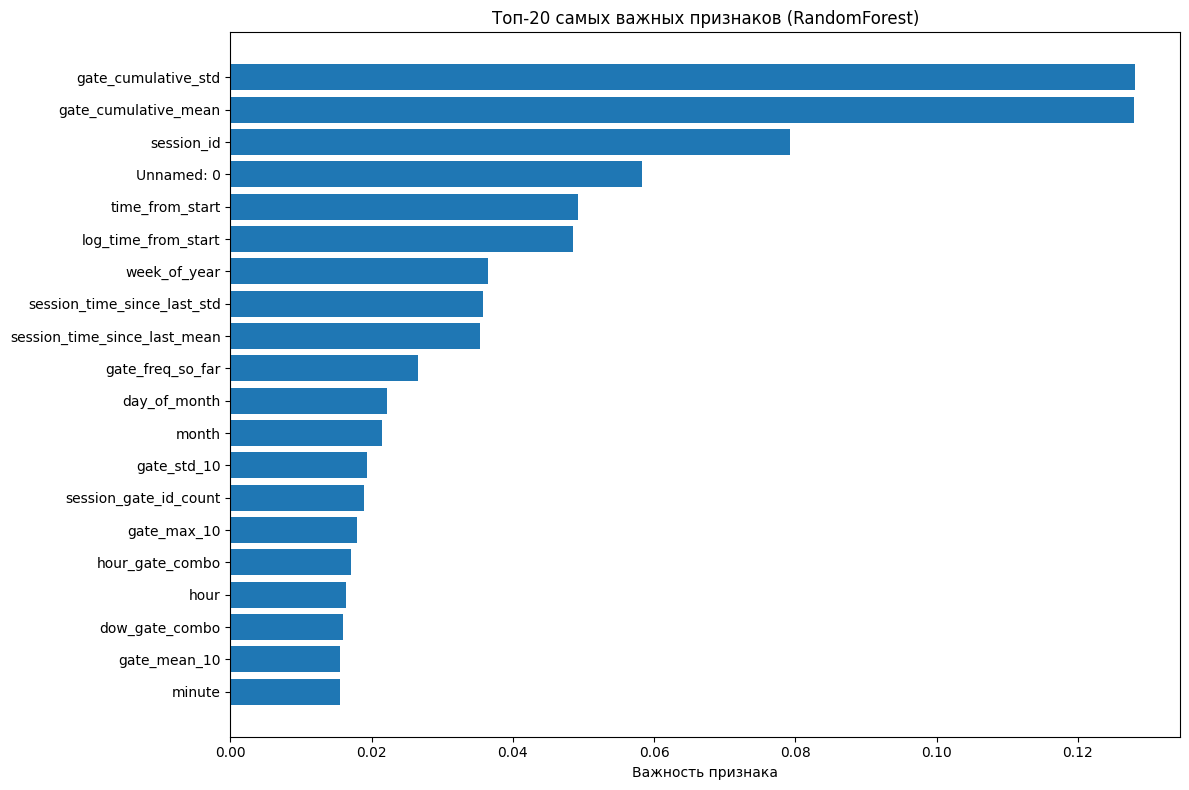


Анализ по группам признаков:
  Временные: 20 признаков, суммарная важность: 0.3841
  Gate статистики: 34 признаков, суммарная важность: 0.5911
  Циклические: 8 признаков, суммарная важность: 0.1273
  Сессии: 5 признаков, суммарная важность: 0.1813
  Повторения: 3 признаков, суммарная важность: 0.0275

ПРЕДСКАЗАНИЕ НА ТЕСТОВЫХ ДАННЫХ

Подготовка тестовых данных...
Выполнение предсказаний...

Агрегация предсказаний...

Статистика предсказаний:
  Всего предсказаний: 7125
  Уникальных user_id предсказано: 38


In [19]:
# ==============================
# 7. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ
# ==============================
print("\n" + "="*50)
print("АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
print("="*50)

if hasattr(best_rf, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nТоп-20 самых важных признаков:")
    for i, row in feature_importance.head(20).iterrows():
        print(f"{i+1:2d}. {row['feature']}: {row['importance']:.6f}")
    
    # Визуализация
    plt.figure(figsize=(12, 8))
    top_n = 20
    top_features = feature_importance.head(top_n)
    plt.barh(range(top_n), top_features['importance'][::-1])
    plt.yticks(range(top_n), top_features['feature'][::-1])
    plt.xlabel('Важность признака')
    plt.title(f'Топ-{top_n} самых важных признаков ({best_model_name})')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Анализ групп признаков
    print("\nАнализ по группам признаков:")
    
    feature_groups = {
        'Временные': ['hour', 'dow', 'minute', 'month', 'week', 'time_since_last', 'time_from_start'],
        'Gate статистики': ['gate_', 'lag', 'diff', 'mean', 'std', 'min', 'max', 'unique', 'cumulative'],
        'Циклические': ['sin', 'cos'],
        'Сессии': ['session_'],
        'Повторения': ['repeat', 'streak', 'freq']
    }
    
    for group_name, keywords in feature_groups.items():
        group_features = [f for f in feature_cols if any(kw in f for kw in keywords)]
        if group_features:
            group_importance = feature_importance[feature_importance['feature'].isin(group_features)]['importance'].sum()
            print(f"  {group_name}: {len(group_features)} признаков, суммарная важность: {group_importance:.4f}")

# ==============================
# 8. ПРЕДСКАЗАНИЕ НА ТЕСТОВЫХ ДАННЫХ
# ==============================
print("\n" + "="*50)
print("ПРЕДСКАЗАНИЕ НА ТЕСТОВЫХ ДАННЫХ")
print("="*50)

# Подготовка тестовых данных
print("\nПодготовка тестовых данных...")

# Убедимся, что тестовые данные имеют те же признаки
missing_in_test = set(feature_cols) - set(test_features.columns)
extra_in_test = set(test_features.columns) - set(feature_cols)

# Добавляем недостающие признаки
for col in missing_in_test:
    test_features[col] = 0

# Удаляем лишние признаки
test_features = test_features[feature_cols + ['user_word']]

# Импутация и масштабирование
X_test_imputed = imputer.transform(test_features[feature_cols])
X_test_scaled = scaler.transform(X_test_imputed)

# Предсказание
print("Выполнение предсказаний...")
test_predictions_encoded = best_model.predict(X_test_scaled)
test_predictions = le_target.inverse_transform(test_predictions_encoded)

# Создаем таблицу соответствий
mapping_df = pd.DataFrame({
    'user_word': test_user_words,
    'predicted_user_id': test_predictions
})

# ==============================
# 9. АГРЕГАЦИЯ ПРЕДСКАЗАНИЙ ДЛЯ КАЖДОГО USER_WORD
# ==============================
print("\nАгрегация предсказаний...")

# Статистика по предсказаниям
prediction_counts = mapping_df['predicted_user_id'].value_counts()
print(f"\nСтатистика предсказаний:")
print(f"  Всего предсказаний: {len(mapping_df)}")
print(f"  Уникальных user_id предсказано: {len(prediction_counts)}")

# Агрегация: для каждого user_word выбираем наиболее частый predicted_user_id
final_mapping_dict = {}

for user_word in mapping_df['user_word'].unique():
    user_predictions = mapping_df[mapping_df['user_word'] == user_word]['predicted_user_id']
    
    # Вычисляем частоты предсказаний
    prediction_counts_user = user_predictions.value_counts()
    
    if len(prediction_counts_user) > 0:
        # Берем наиболее частый предсказанный user_id
        most_common_pred = prediction_counts_user.index[0]
        confidence = prediction_counts_user.iloc[0] / len(user_predictions)
        
        # Если уверенность достаточно высокая
        if confidence >= 0.5:
            final_mapping_dict[user_word] = most_common_pred
        else:
            # Если уверенность низкая, можем попробовать второй по частоте
            if len(prediction_counts_user) > 1:
                second_common = prediction_counts_user.index[1]
                second_confidence = prediction_counts_user.iloc[1] / len(user_predictions)
                
                # Если второй вариант значительно лучше
                if second_confidence > confidence + 0.1:
                    final_mapping_dict[user_word] = second_common
                else:
                    final_mapping_dict[user_word] = most_common_pred
            else:
                final_mapping_dict[user_word] = most_common_pred
    else:
        final_mapping_dict[user_word] = -999

# Для user_word, которые не были обработаны (на всякий случай)
all_test_words = set(test_user_words.unique())
processed_words = set(final_mapping_dict.keys())
unprocessed_words = all_test_words - processed_words

for word in unprocessed_words:
    final_mapping_dict[word] = -999

# Создаем финальный DataFrame
final_result = pd.DataFrame(list(final_mapping_dict.items()), 
                            columns=['user_word', 'preds'])

In [20]:
# ==============================
# 10. АНАЛИЗ И СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ==============================
print("\n" + "="*50)
print("АНАЛИЗ И СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*50)

print(f"\nСтатистика финальных сопоставлений:")
print(f"  Всего user_word: {len(final_result)}")
print(f"  Сопоставлено: {(final_result['preds'] != -999).sum()}")
print(f"  Не сопоставлено (-999): {(final_result['preds'] == -999).sum()}")

# Анализ уникальности предсказаний
if (final_result['preds'] != -999).sum() > 0:
    unique_preds = final_result[final_result['preds'] != -999]['preds'].nunique()
    print(f"  Уникальных preds: {unique_preds}")

# Сохраняем результат
output_file = 'answer_final.csv'
final_result.to_csv(output_file, index=False)
print(f"\nРезультат сохранен в файл: {output_file}")

# ==============================
# 11. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ
# ==============================
print("\n" + "="*50)
print("ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ")
print("="*50)

# Анализ распределения предсказаний по user_id
if (final_result['preds'] != -999).sum() > 0:
    pred_distribution = final_result[final_result['preds'] != -999]['preds'].value_counts()
    print("\nРаспределение предсказаний по user_id:")
    print(f"  Наиболее часто предсказанный user_id: {pred_distribution.index[0]} ({pred_distribution.iloc[0]} раз)")
    print(f"  Всего уникальных предсказанных user_id: {len(pred_distribution)}")

# Анализ уверенности предсказаний
print("\nАнализ уверенности предсказаний:")
for user_word in final_result['user_word'].unique():
    if final_result.loc[final_result['user_word'] == user_word, 'preds'].iloc[0] != -999:
        user_predictions = mapping_df[mapping_df['user_word'] == user_word]['predicted_user_id']
        final_pred = final_result.loc[final_result['user_word'] == user_word, 'preds'].iloc[0]
        confidence = (user_predictions == final_pred).sum() / len(user_predictions)
        
        if confidence < 0.6:
            print(f"  Низкая уверенность для {user_word}: {confidence:.2f}")

print("\n" + "="*50)
print("ВЫПОЛНЕНИЕ ЗАВЕРШЕНО")
print("="*50)


АНАЛИЗ И СОХРАНЕНИЕ РЕЗУЛЬТАТОВ

Статистика финальных сопоставлений:
  Всего user_word: 34
  Сопоставлено: 34
  Не сопоставлено (-999): 0
  Уникальных preds: 5

Результат сохранен в файл: answer_final.csv

ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ

Распределение предсказаний по user_id:
  Наиболее часто предсказанный user_id: 12 (15 раз)
  Всего уникальных предсказанных user_id: 5

Анализ уверенности предсказаний:
  Низкая уверенность для aucroc: 0.12
  Низкая уверенность для binary: 0.26
  Низкая уверенность для blue: 0.25
  Низкая уверенность для categorical: 0.29
  Низкая уверенность для coefficient: 0.23
  Низкая уверенность для collinear: 0.17
  Низкая уверенность для distributed: 0.34
  Низкая уверенность для epsilon: 0.25
  Низкая уверенность для f1: 0.22
  Низкая уверенность для fit: 0.25
  Низкая уверенность для gini: 0.27
  Низкая уверенность для independent: 0.29
  Низкая уверенность для lasso: 0.32
  Низкая уверенность для linear: 0.32
  Низкая уверенность для logistic: 0.40
  Низкая уверенно